In [37]:
import pandas as pd

# Load the CSV files into DataFrames
df_request_log = pd.read_csv('/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/nsgd_constant_poss_7_1000K_eval/request_log.csv')
df_sample = pd.read_csv('/home/kuscu/DRe-SCale/openfaas-functions/state-tracker/logs/nsgd_constant_poss_7_1000K_eval/samples.csv')

# Preview the first 5 rows of request_log.csv
print("Preview of request_log.csv:")
display(df_request_log.head())

# Preview the first 5 rows of sample.csv
print("\nPreview of sample.csv:")
display(df_sample.head())

Preview of request_log.csv:


,timestamp,latency_seconds,rejected,status_code,in_flight,ready_pods,not_ready_pods,cold,idle_on,busy,...,theta_exp,theta_base_stock,theta_base_idle,theta_base_exp,iteration,phase,step_in_phase,phase_budget,agent_cost,mode
0,1.778571e+09,0.0096,True,429,1,1,0,23,0,1,...,2.587875,3.569076,1.050871,2.728318,NaN,NaN,NaN,NaN,NaN,evaluation
1,1.778571e+09,1.9343,False,200,0,1,0,23,1,0,...,2.587875,3.569076,1.050871,2.728318,NaN,NaN,NaN,NaN,NaN,evaluation
2,1.778571e+09,0.0095,True,429,1,1,4,19,0,1,...,2.587875,3.569076,1.050871,2.728318,NaN,NaN,NaN,NaN,NaN,evaluation
3,1.778571e+09,0.0096,True,429,3,1,4,19,0,1,...,2.587875,3.569076,1.050871,2.728318,NaN,NaN,NaN,NaN,NaN,evaluation
4,1.778571e+09,0.0150,True,429,2,1,4,19,0,1,...,2.587875,3.569076,1.050871,2.728318,NaN,NaN,NaN,NaN,NaN,evaluation



Preview of sample.csv:


,timestamp,avg_execution_time,throughput,requests,replicas,avg_cpu,avg_mem,cold,idle_on,busy,...,has_rejection,lstm_ppo_reward,reward_throughput,reward_cpu,reward_mem,reward_replicas,proxy_requests,proxy_rejections,avg_response_latency_ms,p99_response_latency_ms
0,1.778571e+09,0.000,100.00,0,1,0.0031,0.1216,23,1,0,...,False,7501.56,7500.0000,0.0387,1.5200,-0.00,0,0,0.00,0.00
1,1.778571e+09,0.000,100.00,0,1,0.0032,0.1220,23,1,0,...,False,7501.56,7500.0000,0.0400,1.5250,-0.00,0,0,0.00,0.00
2,1.778571e+09,1.923,20.00,5,3,0.0029,0.1224,14,3,0,...,False,300.57,300.0000,0.0362,1.5300,-1.00,8,6,487.28,1910.76
3,1.778571e+09,2.254,81.82,33,10,0.2883,0.1790,14,10,0,...,False,5006.48,5020.8843,3.6037,2.2375,-20.25,34,9,1647.43,6449.23
4,1.778571e+09,1.394,100.00,1,10,0.0332,0.1637,14,9,1,...,False,7482.21,7500.0000,0.4150,2.0463,-20.25,1,0,1397.92,1397.92


In [38]:
WINDOW_MINUTES = 90

def trim_window(df):
    df = df.copy()
    start = df['timestamp'].min()
    df['minutes_from_start'] = (df['timestamp'] - start) / 60
    return df[df['minutes_from_start'] <= WINDOW_MINUTES].reset_index(drop=True)

df_request_log = trim_window(df_request_log)
df_sample = trim_window(df_sample)

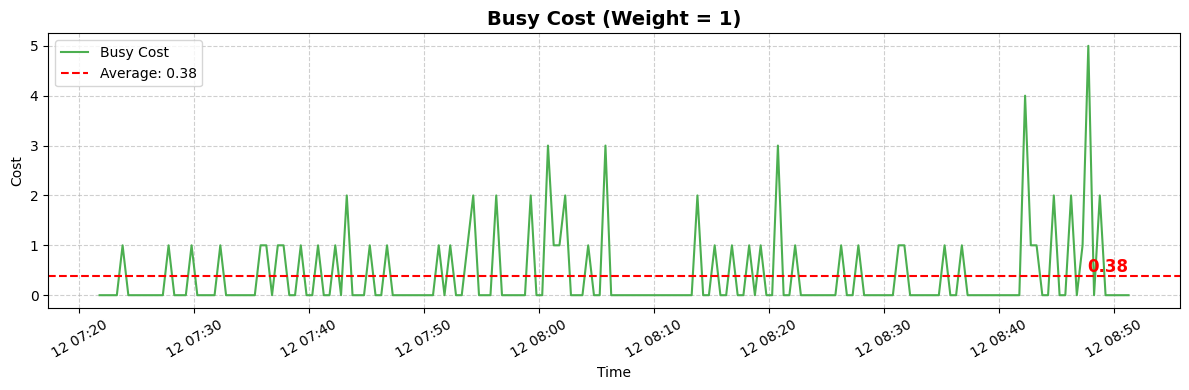

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_sample is already loaded...

# Convert timestamp to readable datetime
df_sample['datetime'] = pd.to_datetime(df_sample['timestamp'], unit='s')

# 2. Define the exact weight for busy
W_BUSY = 1

# 3. Calculate the busy cost component
df_sample['cost_busy'] = df_sample['busy'] * W_BUSY

# --- NEW: Calculate the average (mean) of the busy cost ---
avg_busy_cost = df_sample['cost_busy'].mean()

# 4. Generate and display just the busy cost plot
plt.figure(figsize=(12, 4))

# Plot the main line
plt.plot(df_sample['datetime'], df_sample['cost_busy'], color='#4CAF50', linewidth=1.5, label='Busy Cost')

# --- NEW: Plot the red dashed line for the average ---
plt.axhline(y=avg_busy_cost, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_busy_cost:.2f}')

# --- NEW: Add the exact number at the end of the line ---
# We get the very last datetime value to know where the far right of the graph is
last_timestamp = df_sample['datetime'].max()

# Place the text at the far right edge, slightly above the dashed line
plt.text(last_timestamp, avg_busy_cost, f'{avg_busy_cost:.2f}', 
         color='red', va='bottom', ha='right', fontsize=12, fontweight='bold')

# Formatting
plt.title(f'Busy Cost (Weight = {W_BUSY})', fontsize=14, fontweight='bold')
plt.ylabel('Cost')
plt.xlabel('Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)

# Optional: Adding a legend so the average is clearly labeled
plt.legend()

plt.tight_layout()

# Render the graph
plt.show()

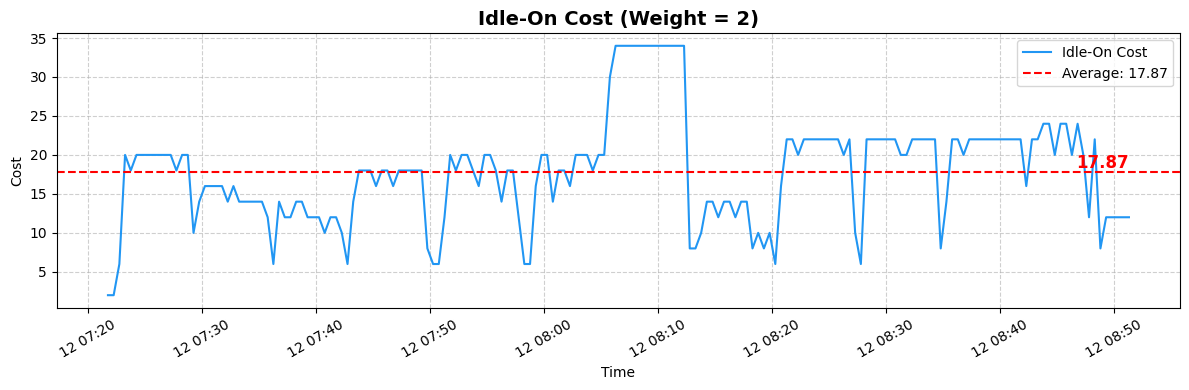

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_sample is already loaded...

# Convert timestamp to readable datetime
df_sample['datetime'] = pd.to_datetime(df_sample['timestamp'], unit='s')

# 2. Define the weight for idle-on
W_IDLE_ON = 2

# 3. Calculate the Idle-On cost component
df_sample['cost_idle'] = df_sample['idle_on'] * W_IDLE_ON

# --- NEW: Calculate the average (mean) of the idle cost ---
avg_idle_cost = df_sample['cost_idle'].mean()

# 4. Generate and display the Idle-On cost plot
plt.figure(figsize=(12, 4))

# Plot the main line (using the blue color from your original list)
plt.plot(df_sample['datetime'], df_sample['cost_idle'], color='#2196F3', linewidth=1.5, label='Idle-On Cost')

# --- NEW: Plot the red dashed line for the average ---
plt.axhline(y=avg_idle_cost, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_idle_cost:.2f}')

# --- NEW: Add the exact number at the end of the line ---
# We get the very last datetime value to know where the far right of the graph is
last_timestamp = df_sample['datetime'].max()

# Place the text at the far right edge, slightly above the dashed line
plt.text(last_timestamp, avg_idle_cost, f'{avg_idle_cost:.2f}', 
         color='red', va='bottom', ha='right', fontsize=12, fontweight='bold')

# Formatting
plt.title(f'Idle-On Cost (Weight = {W_IDLE_ON})', fontsize=14, fontweight='bold')
plt.ylabel('Cost')
plt.xlabel('Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)

# Optional: Adding a legend so the average is clearly labeled
plt.legend()

plt.tight_layout()

# Render the graph
plt.show()

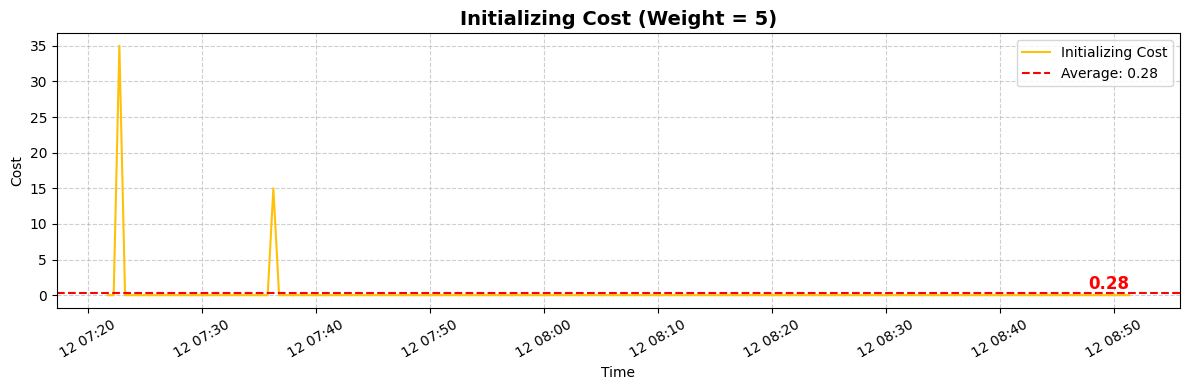

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_sample is already loaded...

# Convert timestamp to readable datetime
df_sample['datetime'] = pd.to_datetime(df_sample['timestamp'], unit='s')

# 2. Define the weight for initialization
W_INIT = 5

# # Create the init_total column by adding free and reserved together
# df_sample['init_total'] = df_sample['init_free'] + df_sample['init_reserved']

# 3. Calculate the Initializing cost component
df_sample['cost_init'] = df_sample['init_total'] * W_INIT

# --- NEW: Calculate the average (mean) of the initializing cost ---
avg_init_cost = df_sample['cost_init'].mean()

# 4. Generate and display the Initializing cost plot
plt.figure(figsize=(12, 4))

# Plot the main line (using the yellow color from your original list)
plt.plot(df_sample['datetime'], df_sample['cost_init'], color='#FFC107', linewidth=1.5, label='Initializing Cost')

# --- NEW: Plot the red dashed line for the average ---
plt.axhline(y=avg_init_cost, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_init_cost:.2f}')

# --- NEW: Add the exact number at the end of the line ---
# We get the very last datetime value to know where the far right of the graph is
last_timestamp = df_sample['datetime'].max()

# Place the text at the far right edge, slightly above the dashed line
plt.text(last_timestamp, avg_init_cost, f'{avg_init_cost:.2f}', 
         color='red', va='bottom', ha='right', fontsize=12, fontweight='bold')

# Formatting
plt.title(f'Initializing Cost (Weight = {W_INIT})', fontsize=14, fontweight='bold')
plt.ylabel('Cost')
plt.xlabel('Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)

# Optional: Adding a legend so the average is clearly labeled
plt.legend()

plt.tight_layout()

# Render the graph
plt.show()

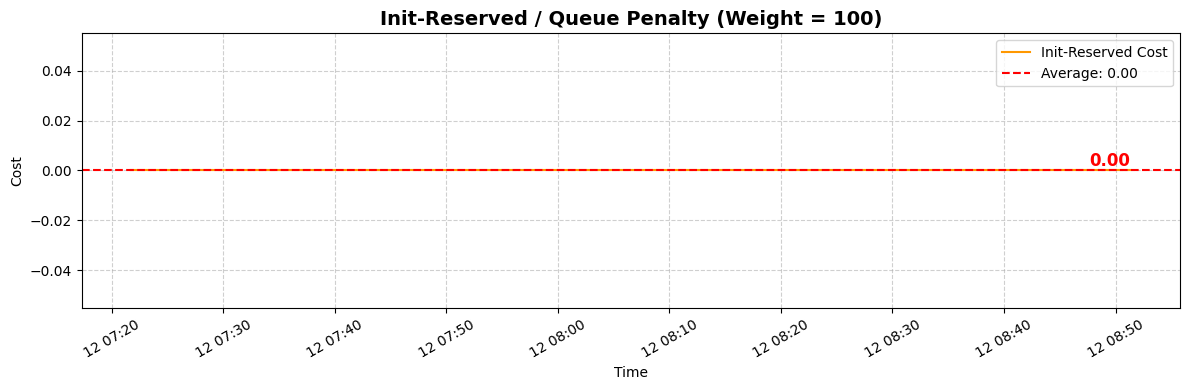

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_sample is already loaded from 'request_log.csv'
# Convert timestamp to readable datetime
df_sample['datetime'] = pd.to_datetime(df_sample['timestamp'], unit='s')

# 2. Define the weight for reserved
W_RESERVED = 100

# 3. Calculate the Reserved cost component
df_sample['cost_reserved'] = df_sample['init_reserved'] * W_RESERVED

# --- NEW: Calculate the average (mean) of the reserved cost ---
avg_reserved_cost = df_sample['cost_reserved'].mean()

# 4. Generate and display the Reserved cost plot
plt.figure(figsize=(12, 4))

# Plot the main line (using the orange color from your original list)
plt.plot(df_sample['datetime'], df_sample['cost_reserved'], color='#FF9800', linewidth=1.5, label='Init-Reserved Cost')

# --- NEW: Plot the red dashed line for the average ---
plt.axhline(y=avg_reserved_cost, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_reserved_cost:.2f}')

# --- NEW: Add the exact number at the end of the line ---
# We get the very last datetime value to know where the far right of the graph is
last_timestamp = df_sample['datetime'].max()

# Place the text at the far right edge, slightly above the dashed line
plt.text(last_timestamp, avg_reserved_cost, f'{avg_reserved_cost:.2f}', 
         color='red', va='bottom', ha='right', fontsize=12, fontweight='bold')

# Formatting
plt.title(f'Init-Reserved / Queue Penalty (Weight = {W_RESERVED})', fontsize=14, fontweight='bold')
plt.ylabel('Cost')
plt.xlabel('Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)

# Optional: Adding a legend so the average is clearly labeled
plt.legend()

plt.tight_layout()

# Render the graph
plt.show()

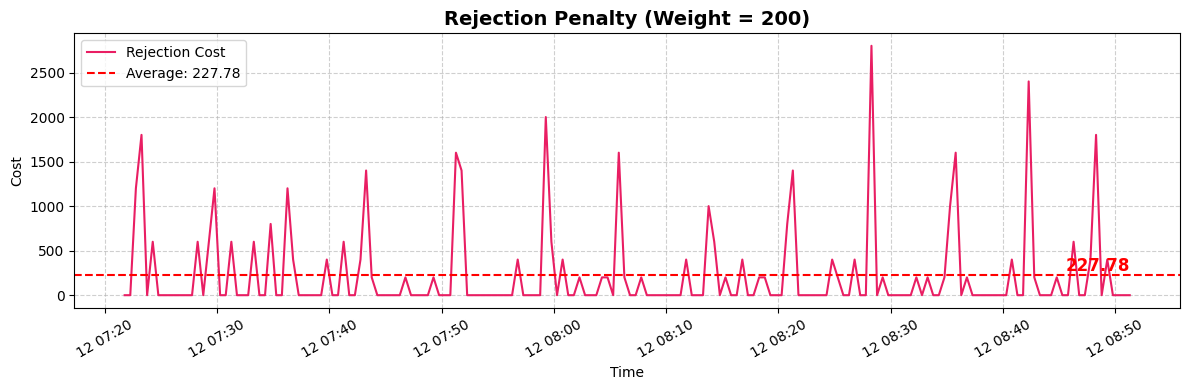

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_sample is already loaded...

# Convert timestamp to readable datetime
df_sample['datetime'] = pd.to_datetime(df_sample['timestamp'], unit='s')

# 2. Define the weight for rejection
W_REJ = 200

# 3. Calculate the Rejection cost component
# df_sample['cost_rejection'] = (df_sample['proxy_rejections'] > 0).astype(int) * W_REJ
df_sample['cost_rejection'] = df_sample['proxy_rejections'] * W_REJ

# --- NEW: Calculate the average (mean) of the rejection cost ---
avg_rejection_cost = df_sample['cost_rejection'].mean()

# 4. Generate and display the Rejection penalty plot
plt.figure(figsize=(12, 4))

# Plot the main line (using the pink/red color from your original list)
plt.plot(df_sample['datetime'], df_sample['cost_rejection'], color='#E91E63', linewidth=1.5, label='Rejection Cost')

# --- NEW: Plot the red dashed line for the average ---
plt.axhline(y=avg_rejection_cost, color='red', linestyle='--', linewidth=1.5, label=f'Average: {avg_rejection_cost:.2f}')

# --- NEW: Add the exact number at the end of the line ---
# We get the very last datetime value to know where the far right of the graph is
last_timestamp = df_sample['datetime'].max()

# Place the text at the far right edge, slightly above the dashed line
plt.text(last_timestamp, avg_rejection_cost, f'{avg_rejection_cost:.2f}', 
         color='red', va='bottom', ha='right', fontsize=12, fontweight='bold')

# Formatting
plt.title(f'Rejection Penalty (Weight = {W_REJ})', fontsize=14, fontweight='bold')
plt.ylabel('Cost')
plt.xlabel('Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=30)

# Optional: Adding a legend so the average is clearly labeled
plt.legend()

plt.tight_layout()

# Render the graph
plt.show()